In [7]:
! pip install spacy

  Using cached spacy-3.8.14-cp312-cp312-win_amd64.whl.metadata (28 kB)
  Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached spacy_loggers-1.0.5-py3-none-any.whl.metadata (23 kB)
  Using cached murmurhash-1.0.15-cp312-cp312-win_amd64.whl.metadata (2.3 kB)
  Using cached cymem-2.0.13-cp312-cp312-win_amd64.whl.metadata (9.9 kB)
  Using cached preshed-3.0.13-cp312-cp312-win_amd64.whl.metadata (5.4 kB)
  Using cached thinc-8.3.13-cp312-cp312-win_amd64.whl.metadata (15 kB)
  Using cached wasabi-1.1.3-py3-none-any.whl.metadata (28 kB)
  Using cached srsly-2.5.3-cp312-cp312-win_amd64.whl.metadata (20 kB)
  Using cached catalogue-2.0.10-py3-none-any.whl.metadata (14 kB)
  Using cached weasel-1.0.0-py3-none-any.whl.metadata (4.6 kB)
  Using cached confection-1.3.3-py3-none-any.whl.metadata (19 kB)
  Using cached typer-0.25.1-py3-none-any.whl.metadata (15 kB)
  Using cached blis-1.3.3-cp312-cp312-win_amd64.whl.metadata (7.7 kB)
  Using cached click-8.4.1-py3-no

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires rich<14,>=10.14.0, but you have rich 15.0.0 which is incompatible.


In [11]:
import os
import csv
import spacy

class Corpus(object):
    def __init__(self, filename):
        self.filename = filename
        self.nlp = spacy.blank("en")

    def __iter__(self):
        with open(self.filename, "r", encoding="utf-8") as i:
            reader = csv.reader(i, delimiter=",")
            
            for _, abstract in reader:
                tokens = [t.text.lower() for t in self.nlp(abstract)]
                yield tokens


documents = Corpus("D:\\Agentic_AI_Internship\\arxiv.csv")



In [12]:
documents

In [13]:
documents = list(documents)
documents[:10]

[['this',
  'paper',
  'investigates',
  'a',
  'cross',
  '-',
  'lingual',
  'document',
  'embedding',
  'method',
  'that',
  '\n',
  'improves',
  'the',
  'current',
  'neural',
  'machine',
  'translation',
  'framework',
  'based',
  'document',
  'vector',
  '\n',
  '(',
  'ntdv',
  'or',
  'simply',
  'nv',
  ')',
  '.',
  'nv',
  'is',
  'developed',
  'with',
  'a',
  'self',
  '-',
  'attention',
  'mechanism',
  'under',
  'the',
  '\n',
  'neural',
  'machine',
  'translation',
  '(',
  'nmt',
  ')',
  'framework',
  '.',
  'in',
  'nv',
  ',',
  'each',
  'pair',
  'of',
  'parallel',
  '\n',
  'documents',
  'in',
  'different',
  'languages',
  'are',
  'projected',
  'to',
  'the',
  'same',
  'shared',
  'layer',
  'in',
  'the',
  '\n',
  'model',
  '.',
  'however',
  ',',
  'the',
  'pair',
  'of',
  'nv',
  'embeddings',
  'are',
  'not',
  'guaranteed',
  'to',
  'be',
  'similar',
  '.',
  '\n',
  'this',
  'paper',
  'further',
  'adds',
  'a',
  'distance',


In [14]:
! pip install gensim

In [15]:
import gensim

model = gensim.models.Word2Vec(documents, min_count=100, window=5, vector_size=100)

Using word embeddings

In [16]:
model.wv["nlp"]

array([-1.3408262 ,  0.44088235,  0.34408072, -0.7581137 ,  0.60724807,
       -0.6656958 ,  0.14604619,  1.2189393 , -0.38114193,  1.7560967 ,
       -0.45701733, -3.35503   ,  1.547603  ,  1.2570153 , -0.16678347,
       -0.33877888, -0.9523666 ,  2.3647883 ,  0.02193098,  0.8531462 ,
       -0.05503003,  0.12655844,  0.26415733,  0.7011198 , -1.7093714 ,
       -2.7675893 ,  1.1084256 ,  0.46230263,  0.60671216, -0.4209996 ,
        0.09426153,  0.04192246,  1.1058743 ,  2.2071507 ,  0.8350311 ,
       -0.04649307,  0.3904553 , -5.699104  , -0.18712611,  2.3516371 ,
       -0.52487   , -1.5015519 ,  2.9233828 ,  0.29627344, -0.40606278,
       -0.7657024 ,  0.99172515,  0.9127337 , -1.7121315 , -2.874427  ,
        0.9906862 ,  2.4110436 , -0.07601345, -1.1227195 , -0.13959284,
       -0.40229163,  0.4445981 ,  1.3584322 ,  3.1705658 ,  0.7596488 ,
       -0.14637962,  2.5195882 , -1.6249658 , -0.41137284, -0.4479609 ,
       -0.8330102 , -0.6035026 , -1.3792218 ,  1.6314832 ,  0.18

In [17]:
print(model.wv.similarity("nmt","smt"))
print(model.wv.similarity("nmt","ner"))

0.66587293
0.42098105


In [18]:
model.wv.similar_by_word("bert", topn = 10)

[('roberta', 0.7986180782318115),
 ('transformer', 0.7583920955657959),
 ('elmo', 0.7137615084648132),
 ('mbert', 0.7038265466690063),
 ('transformers', 0.7026758790016174),
 ('pretrained', 0.6891613006591797),
 ('xlnet', 0.6843917369842529),
 ('xlm', 0.6750783324241638),
 ('gpt-2', 0.6353132724761963),
 ('lstm', 0.6132026314735413)]

In [19]:
model.wv.most_similar(positive=["transformer","lstm"], negative=["bert"], topn=10)

[('rnn', 0.7804284691810608),
 ('recurrent', 0.7499306201934814),
 ('attentional', 0.7387697100639343),
 ('gru', 0.7369261980056763),
 ('convolution', 0.7235429286956787),
 ('stacked', 0.7176303863525391),
 ('gated', 0.70163494348526),
 ('bilstm', 0.6788378953933716),
 ('forward', 0.671044111251831),
 ('encoder', 0.6673124432563782)]

In [20]:
model.wv.most_similar(positive=["tree"],topn=10)

[('trees', 0.7885719537734985),
 ('constituency', 0.7263596057891846),
 ('parse', 0.6965784430503845),
 ('recursive', 0.6909776329994202),
 ('constituent', 0.6348839998245239),
 ('dependency', 0.625170111656189),
 ('formalism', 0.6045783758163452),
 ('syntax', 0.6015142202377319),
 ('parser', 0.5993019342422485),
 ('amr', 0.5707967281341553)]

In [21]:
print(model.wv.doesnt_match("lstm cnn gru svm transformer".split()))

svm


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

target_word="bert"
selected_words=[w[0] for w in model.wv.most_similar(positive=[target_word],topn=200)]+[target_word]
embeddings=[model.wv[w] for w in selected_words]+model.wv["bert"]

mapped_embeddings=TSNE(n_components=2,metric="cosine",init="pca").fit_transform(embeddings)

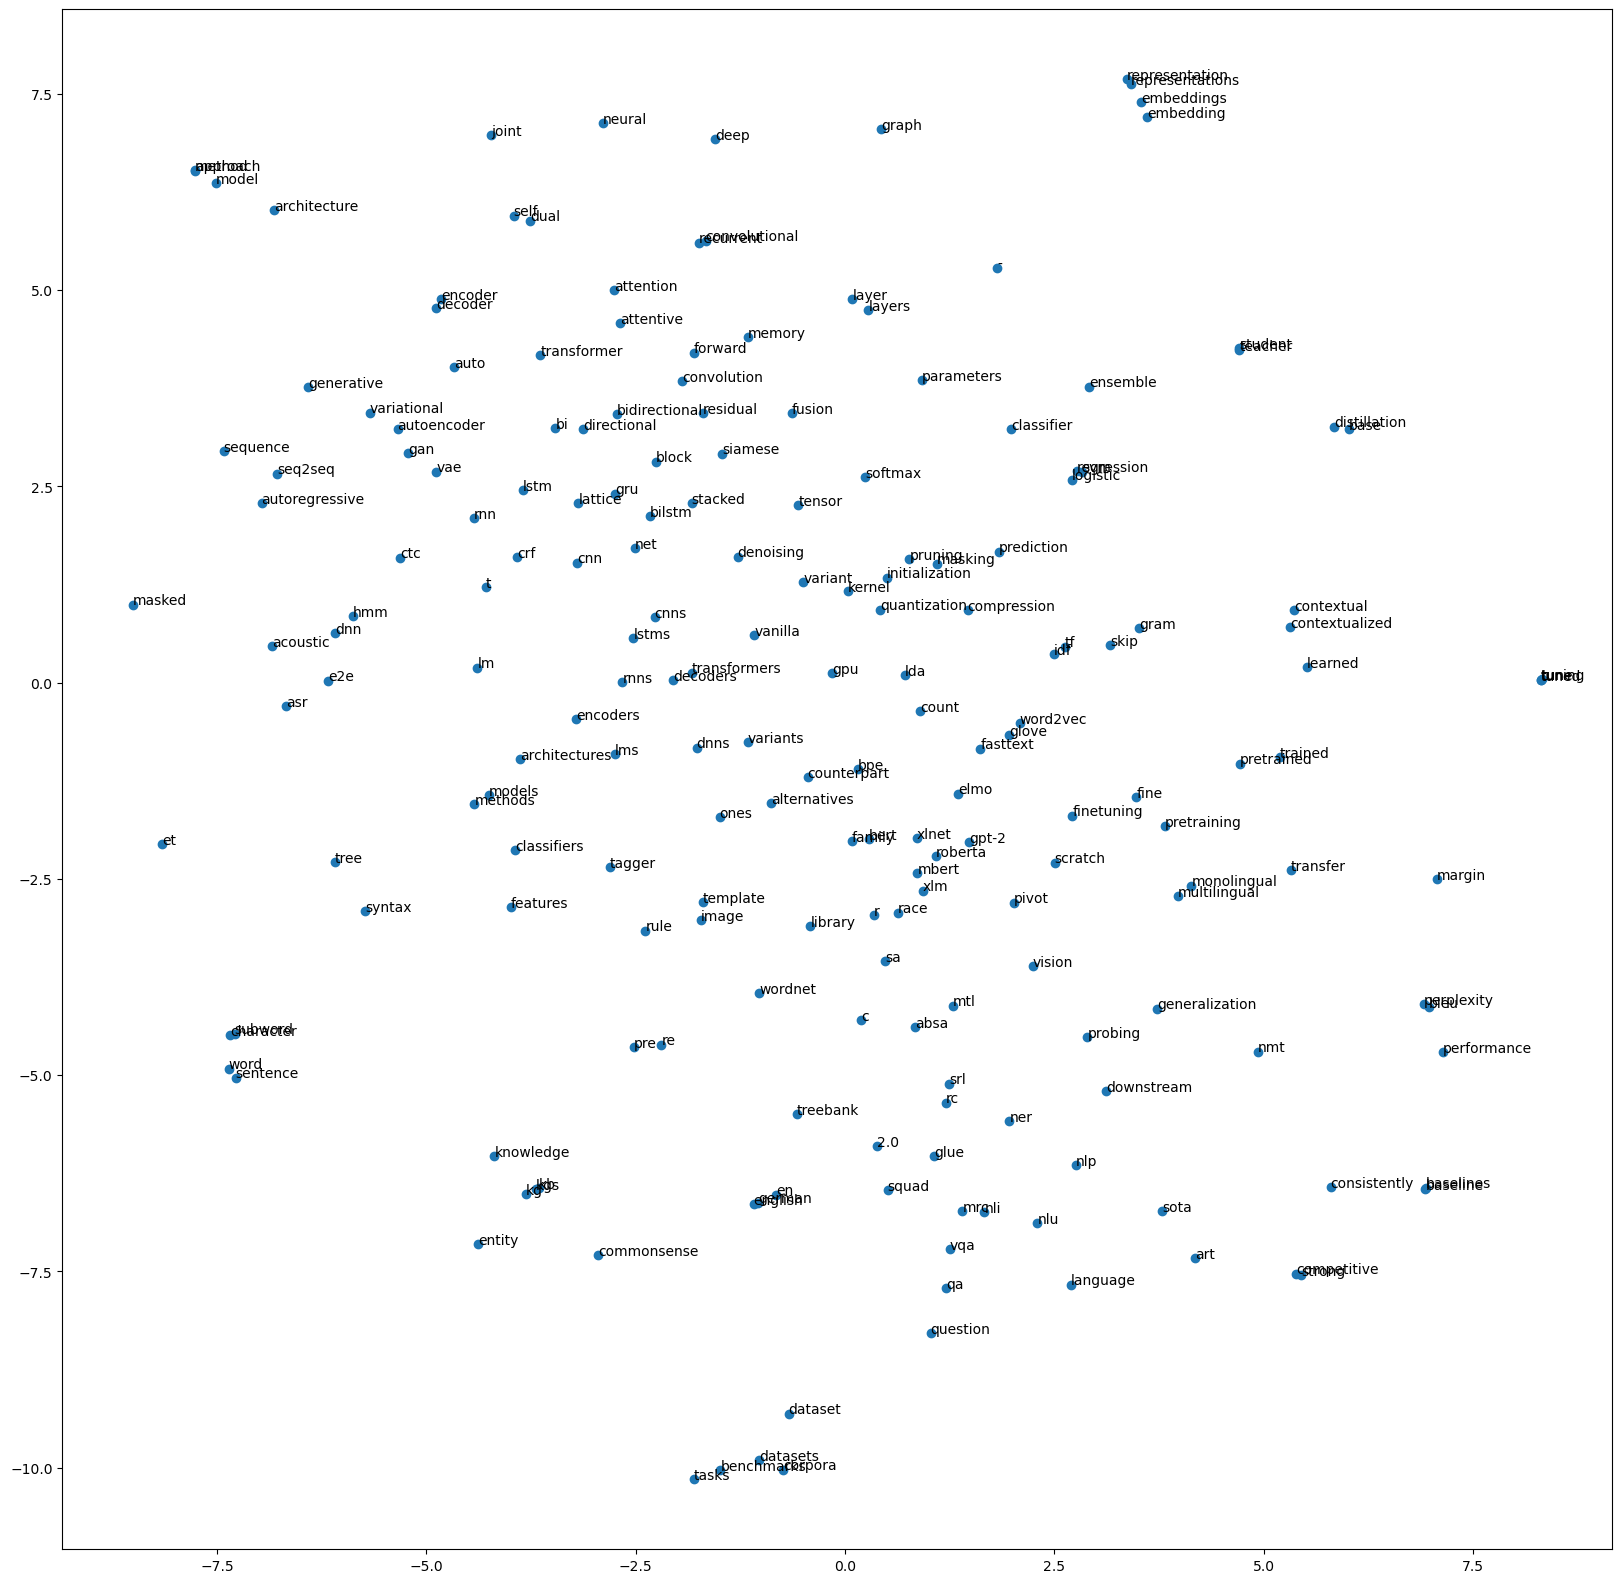

In [26]:
plt.figure(figsize=(20,20))
x=mapped_embeddings[:,0]
y=mapped_embeddings[:,1]
plt.scatter(x,y)
for i, txt in enumerate(selected_words):
    plt.annotate(txt, (x[i], y[i]))